In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

Dataset: <br>
League - New All, Expanded Features <br>
Year(s) - 2021-25 <br>

In [13]:
# Test new set loading / verify the same format compared to original Final_DataSet_All_Fixed.csv
df = pd.read_csv('../data/v5/All_Data_Final_Fixed.csv')
pd.set_option('display.max_columns', None)
df

,Game_ID,Season,Matchweek,Game_Type,Time,Team,Home_Score,Away_Score,Home_Red_Count,Away_Red_Count,Home_Yellow_Count,Away_Yellow_Count,Home_First_Red_Time,Away_First_Red_Time,Home_Total_Sub_Count,Away_Total_Sub_Count,Event_Type,Player_1,Pos_1,Player_2,Pos_2,Note,Odds_Home_Win,Odds_Draw,Odds_Away_Win,Home_Defensive_Sub_Count,Home_Offensive_Sub_Count,Home_Neutral_Sub_Count,Away_Defensive_Sub_Count,Away_Offensive_Sub_Count,Away_Neutral_Sub_Count
0,120230101,2023,1,League,20,Away,0,1,0,0,0,0,NaN,NaN,0,0,GOAL,Isi Palazón,NaN,NaN,NaN,GOAL,2.63,3.16,2.87,0,0,0,0,0,0
1,120230101,2023,1,League,28,Away,0,2,0,0,0,0,NaN,NaN,0,0,GOAL,Randy Ntekja,NaN,NaN,NaN,GOAL,2.63,3.16,2.87,0,0,0,0,0,0
2,120230101,2023,1,League,40,Away,0,2,0,0,0,1,NaN,NaN,0,0,YELLOW,Unai López,NaN,NaN,NaN,YELLOW,2.63,3.16,2.87,0,0,0,0,0,0
3,120230101,2023,1,League,46,Away,0,2,0,0,0,1,NaN,NaN,0,1,SUBSTITUTION,Pathé Ciss,Central Midfield,Unai López,NaN,NEUTRAL SUBSTITUTION,2.63,3.16,2.87,0,0,0,0,0,1
4,120230101,2023,1,League,46,Home,0,2,0,0,0,1,NaN,NaN,1,1,SUBSTITUTION,Sergio Arribas,Midfield,Lázaro,NaN,NEUTRAL SUBSTITUTION,2.63,3.16,2.87,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85491,520253403,2025,34,League,77,Away,0,2,0,0,0,3,NaN,NaN,3,4,SUBSTITUTION,Paulo Dybala,Offence,Donyell Malen,NaN,OFFENSIVE SUBSTITUTION,2.95,3.21,2.43,1,1,1,2,2,0
85492,520253403,2025,34,League,77,Home,0,2,0,0,0,3,NaN,NaN,4,4,SUBSTITUTION,Nicolò Cambiaghi,Offence,Riccardo Orsolini,NaN,OFFENSIVE SUBSTITUTION,2.95,3.21,2.43,1,2,1,2,2,0
85493,520253403,2025,34,League,77,Home,0,2,0,0,0,3,NaN,NaN,5,4,SUBSTITUTION,Martin Vitík,Defence,Eivind Helland,NaN,NEUTRAL SUBSTITUTION,2.95,3.21,2.43,1,2,2,2,2,0
85494,520253403,2025,34,League,90,Away,0,2,0,0,0,3,NaN,NaN,5,5,SUBSTITUTION,Jan Ziółkowski,Defence,Niccolo Pisilli,NaN,NEUTRAL SUBSTITUTION,2.95,3.21,2.43,1,2,2,2,2,1


In [14]:
# --- 1. DATA PREPARATION ---
df = pd.read_csv('../data/v5/All_Data_Final_Fixed.csv')
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

df['Game_ID'] = df['Game_ID'].astype(str)

# OUTCOME MAPPING (Derived from 'Final Result' events)
final_results = df[df['Event_Type'] == 'FINAL RESULT'].copy()
conditions = [
    (final_results['Home_Score'] > final_results['Away_Score']),
    (final_results['Away_Score'] > final_results['Home_Score']),
    (final_results['Home_Score'] == final_results['Away_Score'])
]
choices = ['Home_Win', 'Away_Win', 'Draw']
final_results['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')

outcome_map = dict(zip(final_results['Game_ID'], final_results['Match_Outcomes']))
df['Match_Outcomes'] = df['Game_ID'].map(outcome_map)

# Data Cleaning: Remove unknowns and result rows to prevent data leakage
df = df.dropna(subset=['Match_Outcomes'])
df = df[df['Match_Outcomes'] != 'Unknown'].copy()
df_mod = df[df['Event_Type'] != 'Final Result'].copy()

# Feature Engineering
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])
df_mod['Home_Odds_Log'] = np.log1p(df_mod['Odds_Home_Win'].fillna(0))
df_mod['Draw_Odds_Log'] = np.log1p(df_mod['Odds_Draw'].fillna(0))
df_mod['Away_Odds_Log'] = np.log1p(df_mod['Odds_Away_Win'].fillna(0))
df_mod['Time_Bin'] = (df_mod['Time'] // 5).astype(int)

# Standardized Outcome Colors (Coolwarm-inspired)
outcome_colors = {'Home_Win': "#4b5dd6", 'Away_Win': "#b44a04", 'Draw': "#dddddd8f"}

features_n = [
    'Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
    'Home_Red_Count', 'Away_Red_Count', 'Home_Yellow_Count', 'Away_Yellow_Count',
    'Home_Defensive_Sub_Count', 'Home_Offensive_Sub_Count', 'Home_Neutral_Sub_Count',
    'Away_Defensive_Sub_Count', 'Away_Offensive_Sub_Count', 'Away_Neutral_Sub_Count',
    'Home_Odds_Log', 'Draw_Odds_Log', 'Away_Odds_Log'
]

In [15]:
# PART A: NORMAL TIME ANALYSIS (STAGES 1, 2, 3)
# =================================================================
print("--- PART A: NORMAL TIME ---")
X_n = df_mod[features_n]
y_n = df_mod['Match_Outcomes']
X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(X_n, y_n, test_size=0.2, random_state=42, stratify=y_n)

--- PART A: NORMAL TIME ---


In [16]:
# Stage 1: Baseline with Optimal K Search
print("Searching for Optimal Baseline K (Normal Time)...")
base_search_n = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': range(1, 41)}, cv=5, scoring='f1_weighted'
)
base_search_n.fit(X_tr_n, y_tr_n)
best_k_n = base_search_n.best_params_['knn__n_neighbors']
print(f"Optimal Normal K: {best_k_n}")

Searching for Optimal Baseline K (Normal Time)...
Optimal Normal K: 40


In [17]:
# Stage 2: Optimized Model
smote_n = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)), 
    ('pca', PCA(n_components=6)), 
    ('knn', KNeighborsClassifier(n_neighbors=best_k_n, weights='distance'))
])
smote_n.fit(X_tr_n, y_tr_n)
y_pred_n = smote_n.predict(X_te_n)

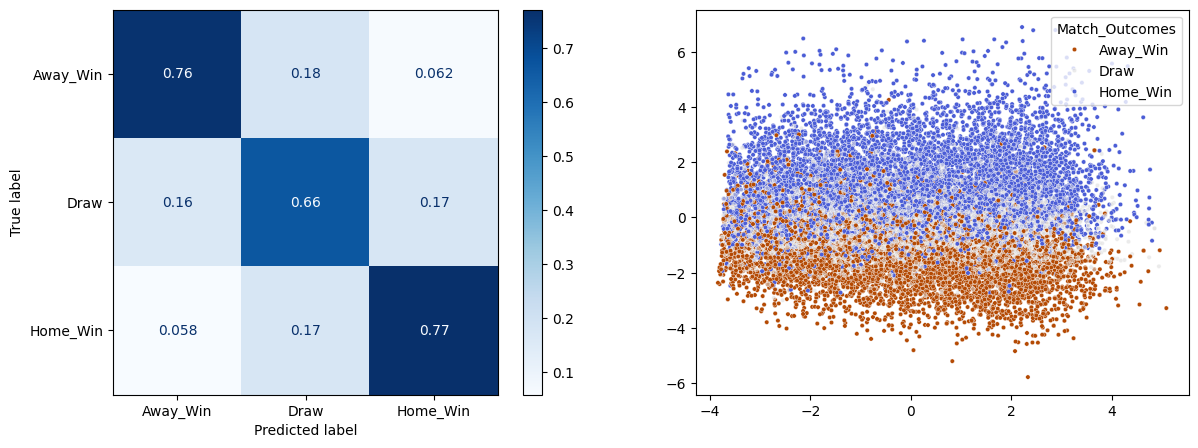

In [18]:
# Stage 1-2 Visuals
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_te_n, y_pred_n, cmap='Blues', normalize='true', ax=ax[0])
X_pca_n = base_search_n.best_estimator_.named_steps['pca'].transform(base_search_n.best_estimator_.named_steps['scaler'].transform(X_te_n))
sns.scatterplot(x=X_pca_n[:, 0], y=X_pca_n[:, 1], hue=y_te_n, palette=outcome_colors, s=10, ax=ax[1])
plt.show()

--- Stage 3: Normal Time Accuracy Evolution ---


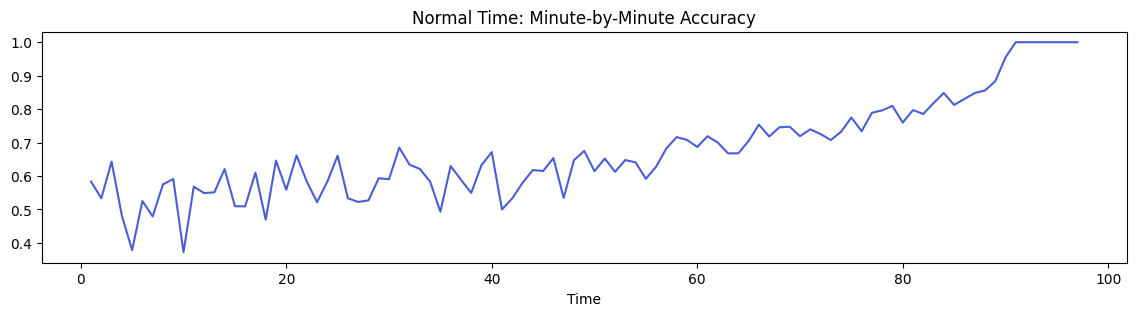

In [19]:
# Stage 3: Normal Accuracy Evolution
print("--- Stage 3: Normal Time Accuracy Evolution ---")
acc_n = X_te_n.copy()
acc_n['A'], acc_n['P'] = y_te_n, y_pred_n
plt.figure(figsize=(14, 3))
acc_n.groupby('Time').apply(lambda x: accuracy_score(x['A'], x['P']), include_groups=False).plot(color='#4b5dd6')
plt.title("Normal Time: Minute-by-Minute Accuracy")
plt.show()

In [20]:
# PART B: BINNED TIME ANALYSIS (STAGES 4, 5, 6)
# =================================================================
print("\n--- PART B: BINNED TIME ---")
features_b = [f if f != 'Time' else 'Time_Bin' for f in features_n]
X_b = df_mod[features_b]
y_b = df_mod['Match_Outcomes']
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)


--- PART B: BINNED TIME ---


In [21]:
# Stage 4: Baseline with Optimal K Search
print("Searching for Optimal Baseline K (Binned Time)...")
base_search_b = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=2)), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': range(1, 41)}, cv=5, scoring='f1_weighted'
)
base_search_b.fit(X_tr_b, y_tr_b)
best_k_b = base_search_b.best_params_['knn__n_neighbors']
print(f"Optimal Binned K: {best_k_b}")

Searching for Optimal Baseline K (Binned Time)...
Optimal Binned K: 36


In [22]:
# Stage 5: Optimized Model
smote_b = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)), 
    ('pca', PCA(n_components=6)), 
    ('knn', KNeighborsClassifier(n_neighbors=best_k_b, weights='distance'))
])
smote_b.fit(X_tr_b, y_tr_b)
y_pred_b = smote_b.predict(X_te_b)

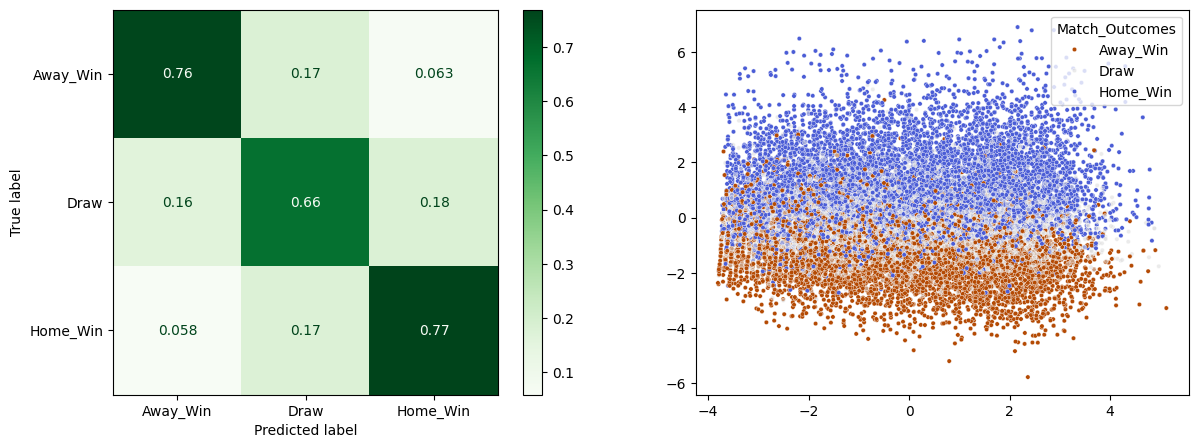

In [23]:
# Stage 4-5 Visuals
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_te_b, y_pred_b, cmap='Greens', normalize='true', ax=ax[0])
X_pca_b = base_search_b.best_estimator_.named_steps['pca'].transform(base_search_b.best_estimator_.named_steps['scaler'].transform(X_te_b))
sns.scatterplot(x=X_pca_b[:, 0], y=X_pca_b[:, 1], hue=y_te_b, palette=outcome_colors, s=10, ax=ax[1])
plt.show()

--- Stage 6: Binned Time Accuracy Evolution ---


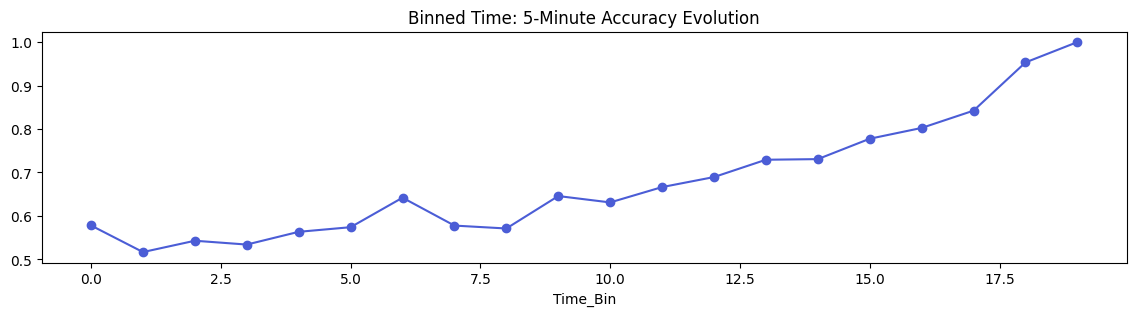

In [24]:
# Stage 6: Binned Accuracy Evolution
print("--- Stage 6: Binned Time Accuracy Evolution ---")
acc_b = X_te_b.copy()
acc_b['A'], acc_b['P'] = y_te_b, y_pred_b
plt.figure(figsize=(14, 3))
acc_b.groupby('Time_Bin').apply(lambda x: accuracy_score(x['A'], x['P']), include_groups=False).plot(kind='line', marker='o', color='#4b5dd6')
plt.title("Binned Time: 5-Minute Accuracy Evolution")
plt.show()


--- STAGE 7: COMPREHENSIVE FEATURE MAPPING ---


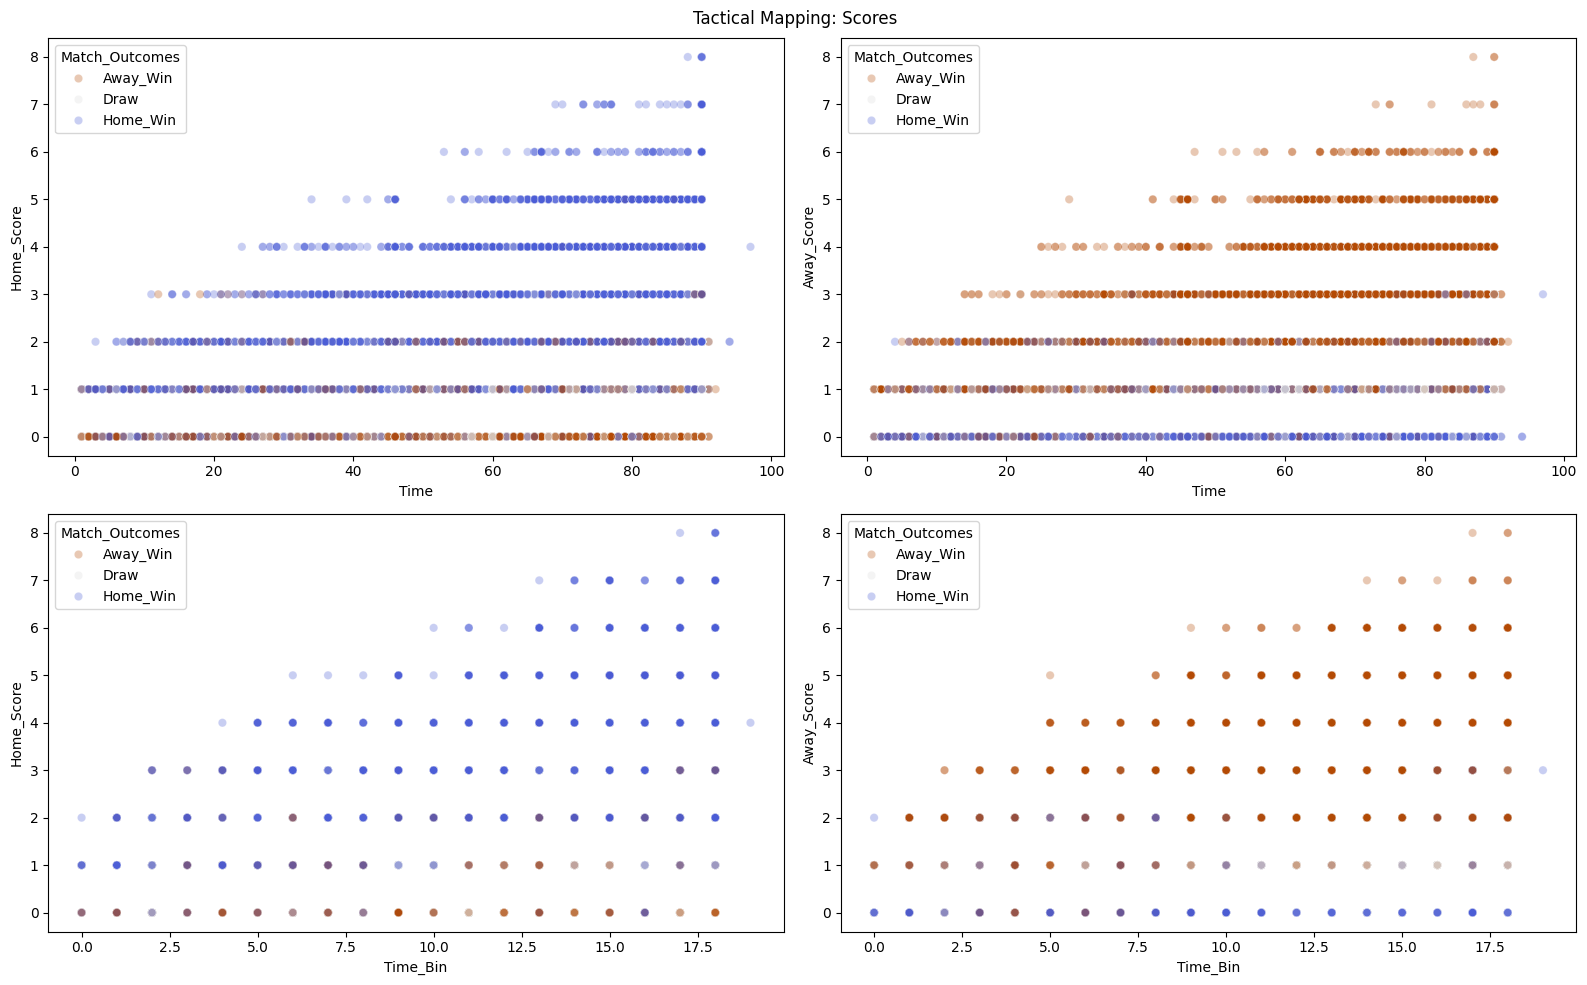

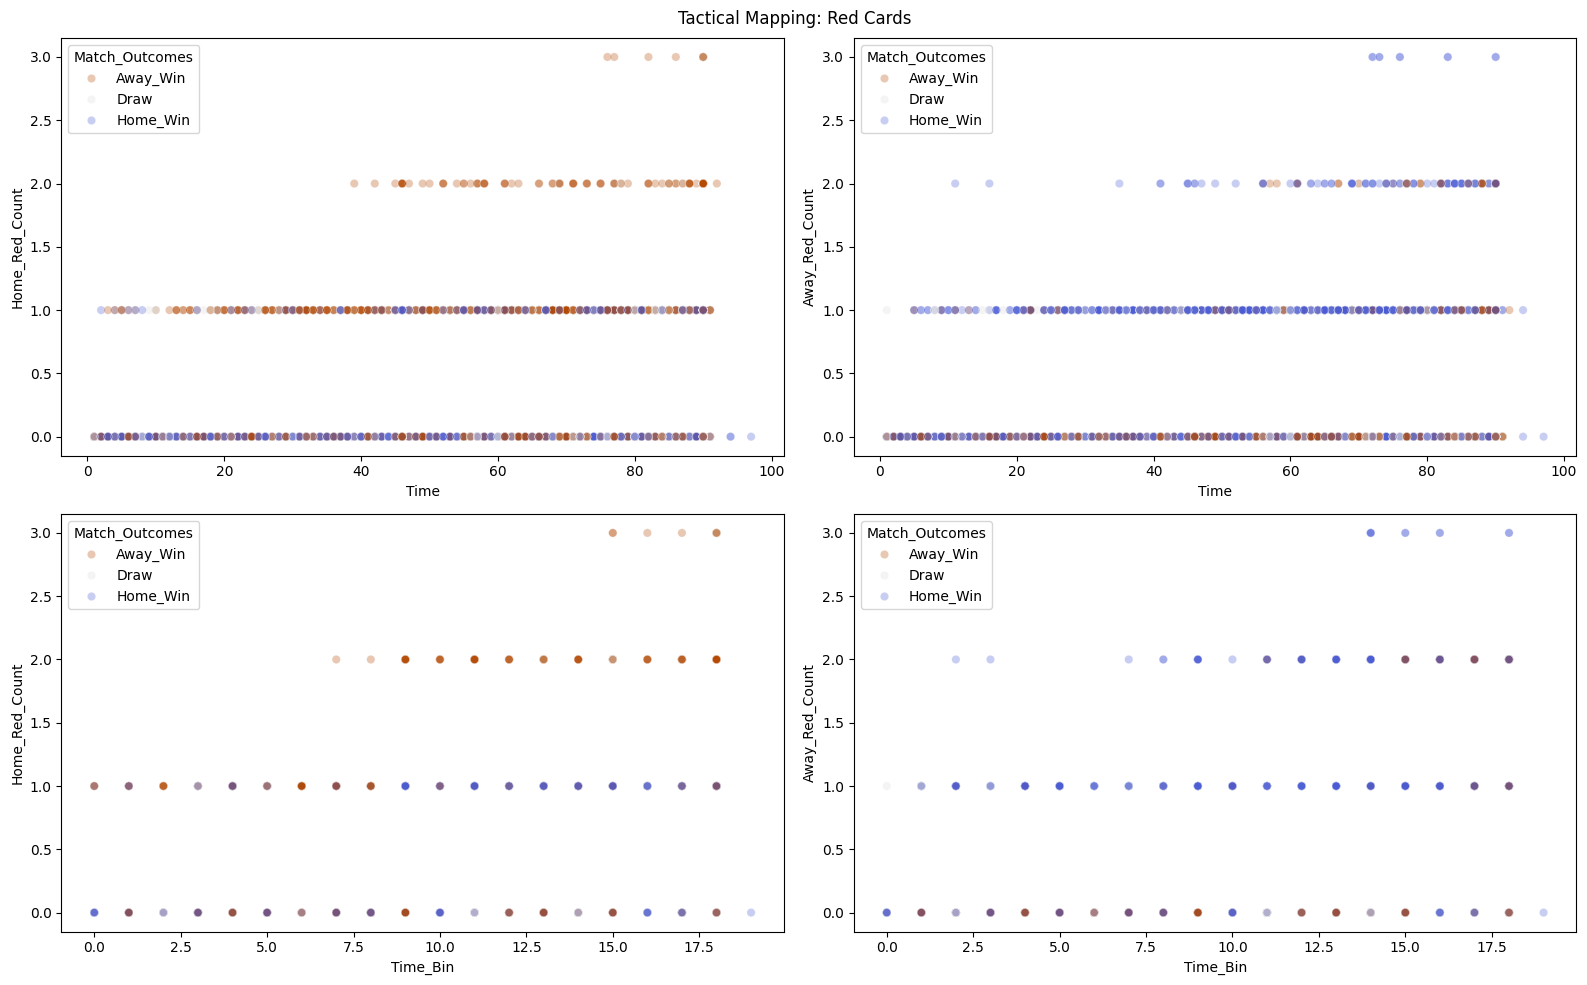

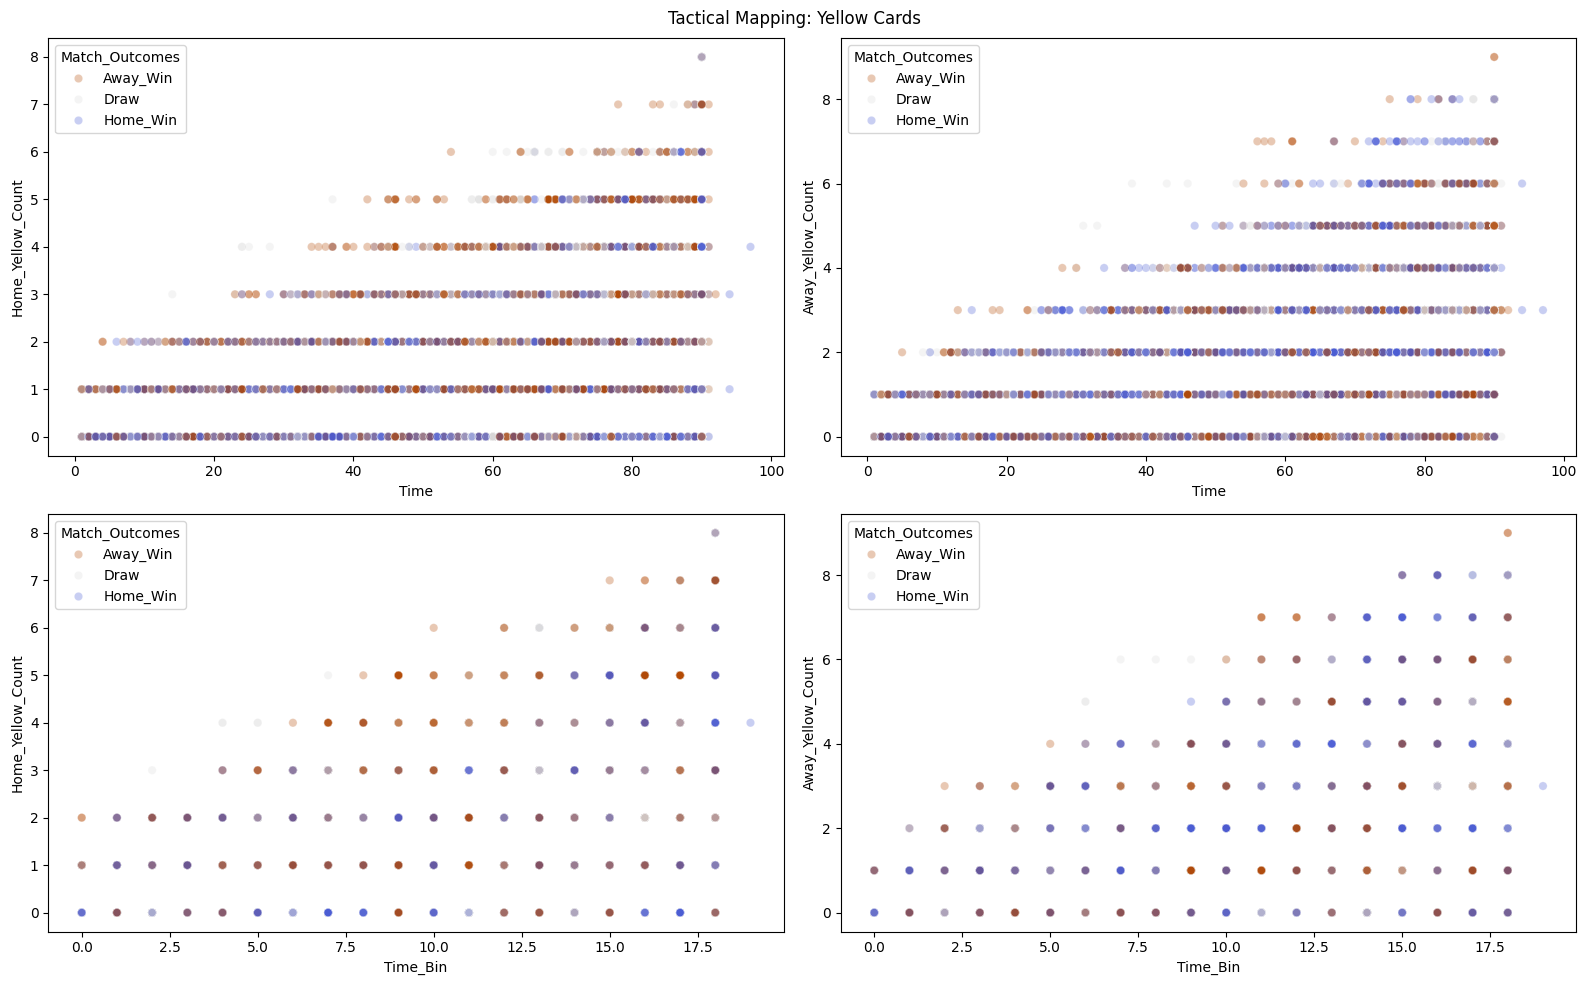

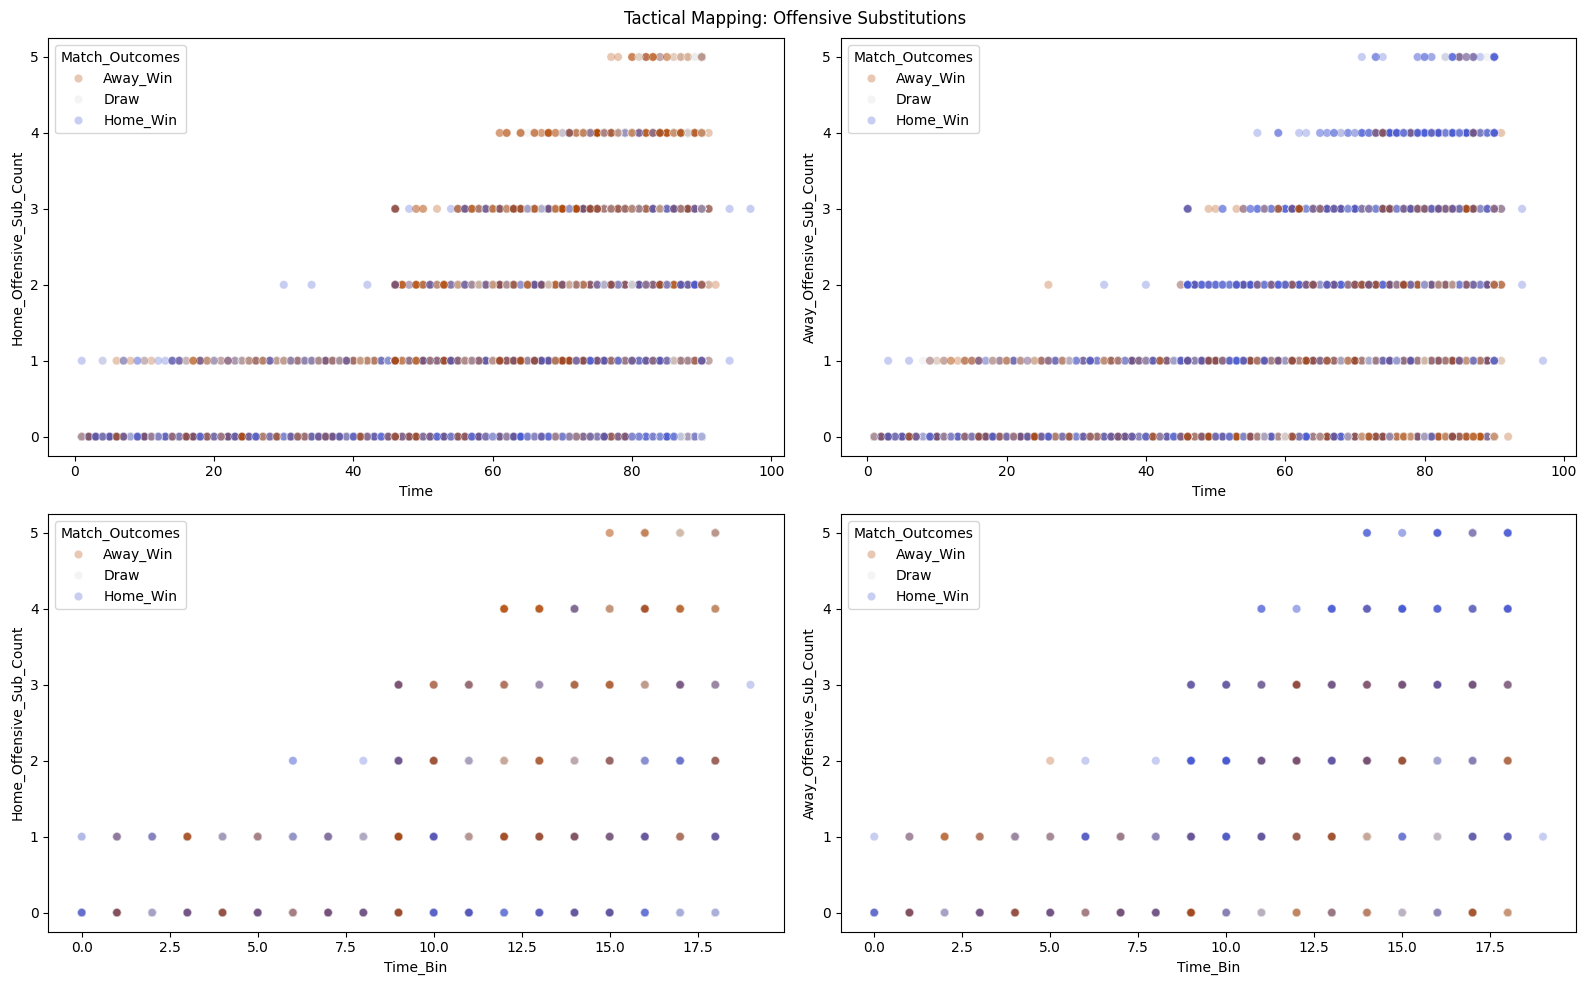

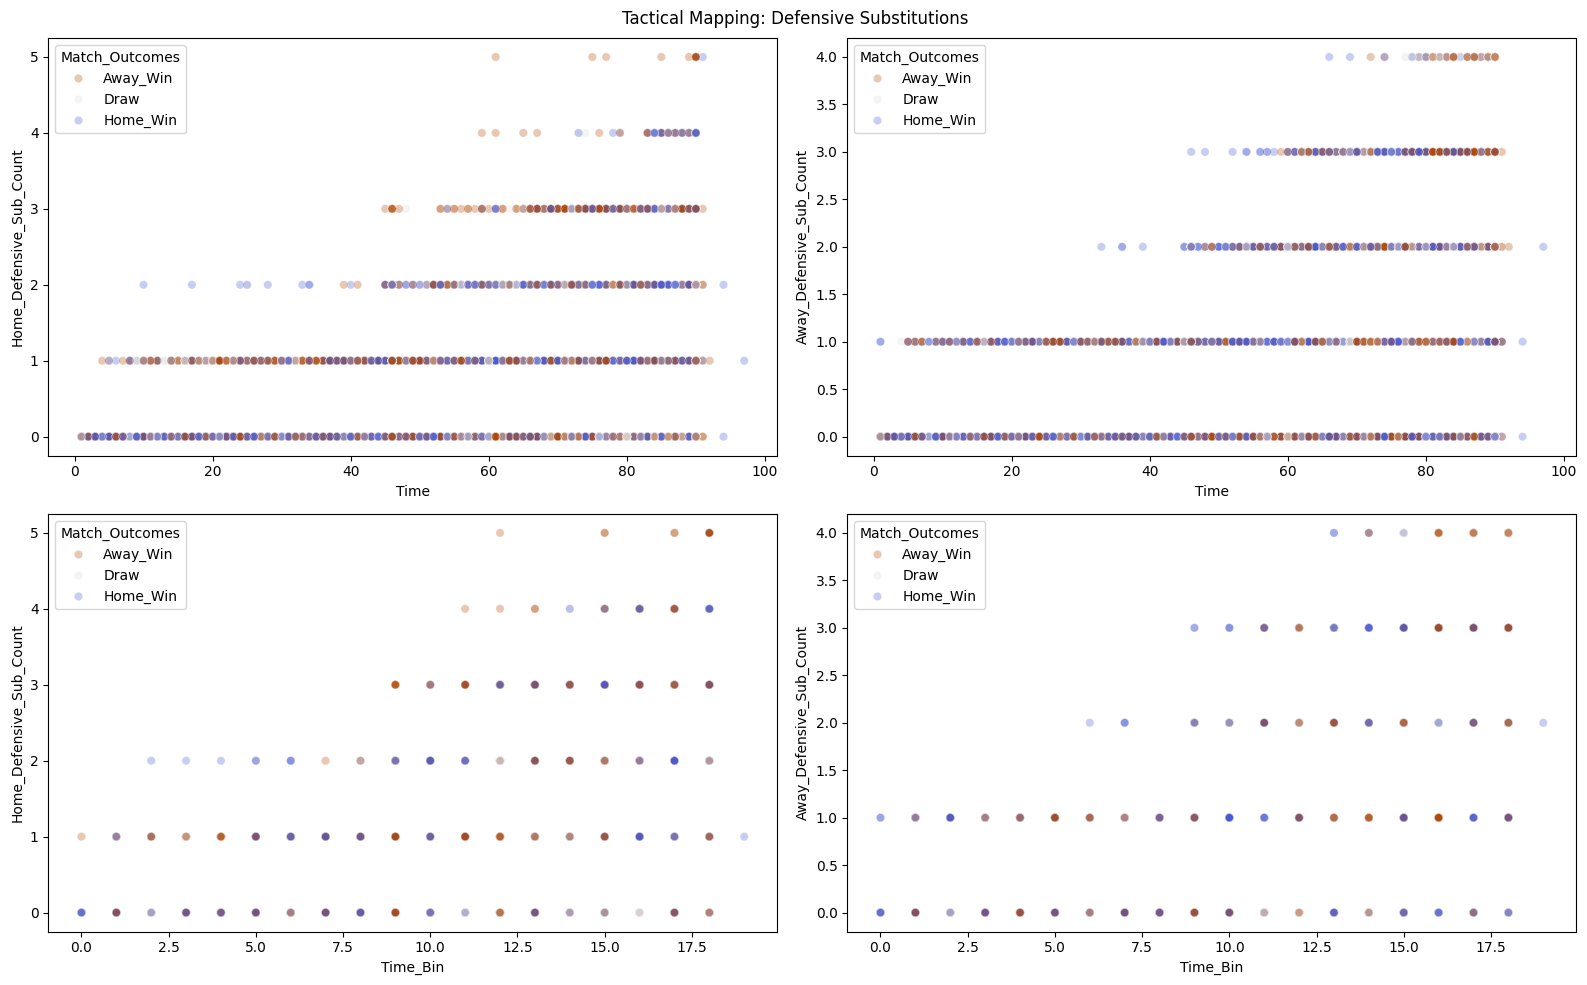

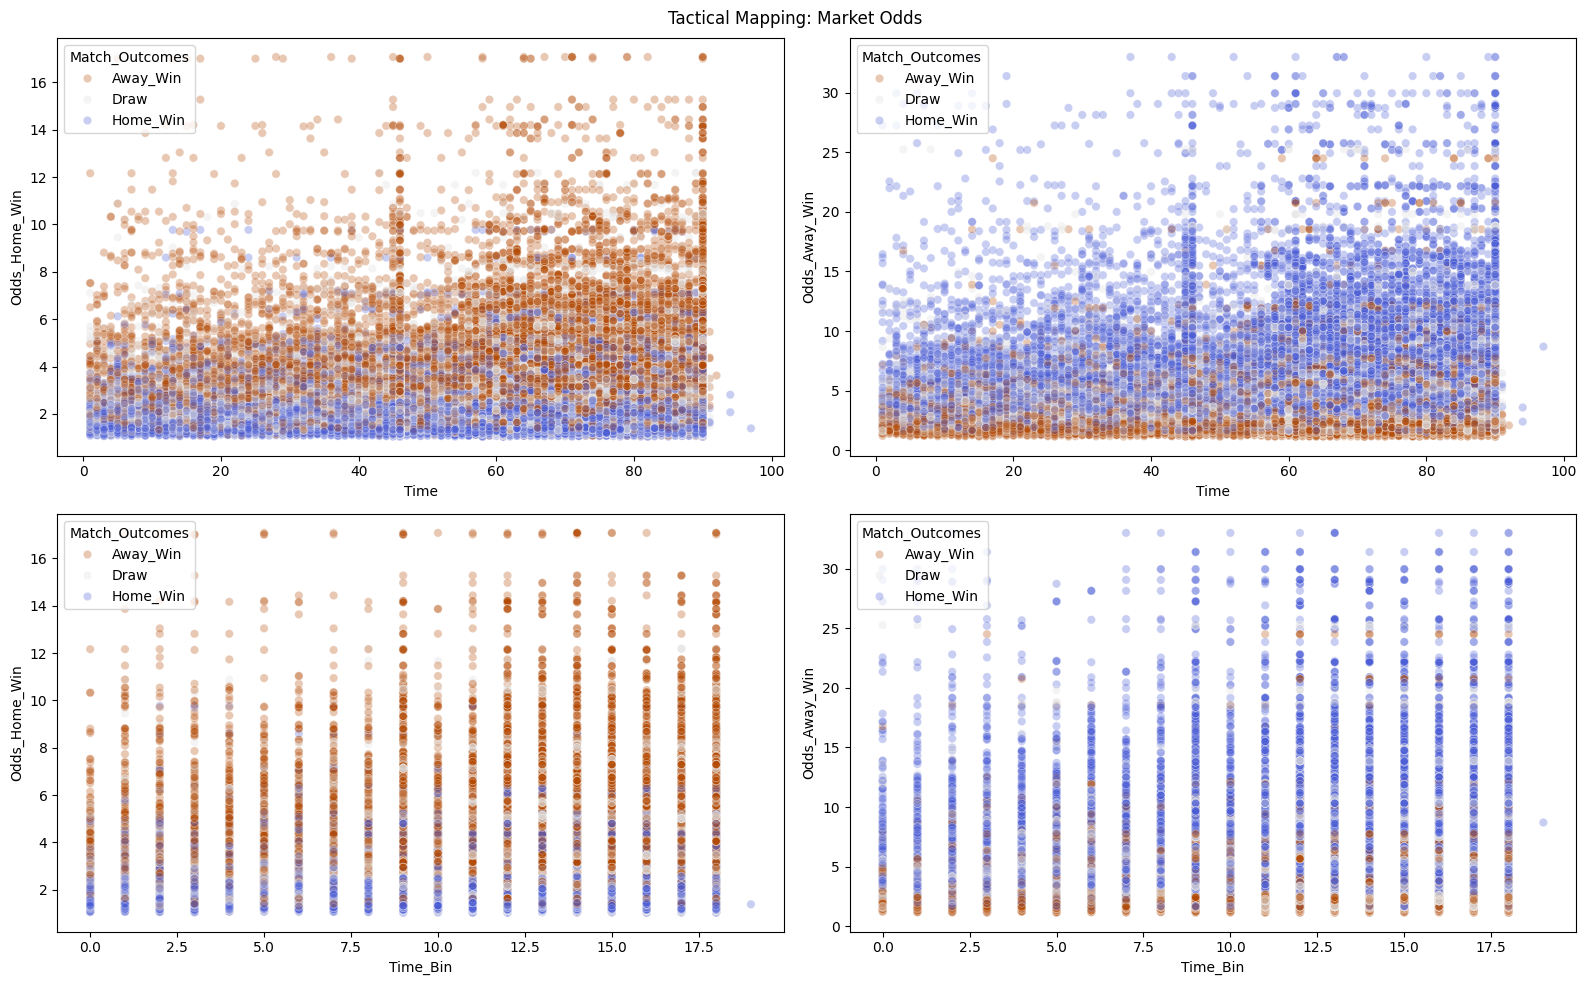

C:\Users\matth\AppData\Local\Temp\ipykernel_20944\4234090534.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.importances_mean, y=features_b, palette='mako')


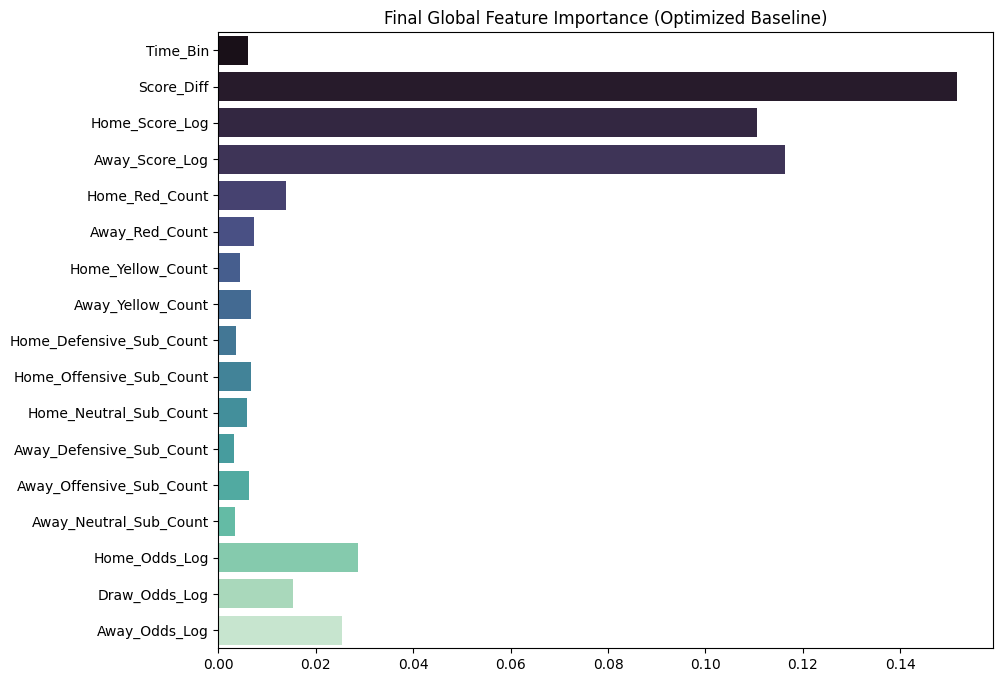

In [25]:
# STAGE 7: COMPREHENSIVE TACTICAL MAPPING
# =================================================================
print("\n--- STAGE 7: COMPREHENSIVE FEATURE MAPPING ---")

def plot_feature_grid_final(h_feat, a_feat, title_name):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    # Row 1: Normal Time
    sns.scatterplot(data=df_mod, x="Time", y=h_feat, hue="Match_Outcomes", palette=outcome_colors, alpha=0.3, ax=axes[0,0])
    sns.scatterplot(data=df_mod, x="Time", y=a_feat, hue="Match_Outcomes", palette=outcome_colors, alpha=0.3, ax=axes[0,1])
    # Row 2: Binned Time
    sns.scatterplot(data=df_mod, x="Time_Bin", y=h_feat, hue="Match_Outcomes", palette=outcome_colors, alpha=0.3, ax=axes[1,0])
    sns.scatterplot(data=df_mod, x="Time_Bin", y=a_feat, hue="Match_Outcomes", palette=outcome_colors, alpha=0.3, ax=axes[1,1])
    plt.suptitle(f"Tactical Mapping: {title_name}")
    plt.tight_layout()
    plt.show()

# Tactical Feature Grids
plot_feature_grid_final("Home_Score", "Away_Score", "Scores")
plot_feature_grid_final("Home_Red_Count", "Away_Red_Count", "Red Cards")
plot_feature_grid_final("Home_Yellow_Count", "Away_Yellow_Count", "Yellow Cards")
plot_feature_grid_final("Home_Offensive_Sub_Count", "Away_Offensive_Sub_Count", "Offensive Substitutions")
plot_feature_grid_final("Home_Defensive_Sub_Count", "Away_Defensive_Sub_Count", "Defensive Substitutions")
plot_feature_grid_final("Odds_Home_Win", "Odds_Away_Win", "Market Odds")

# Global Feature Importance
imp = permutation_importance(smote_b, X_te_b, y_te_b, n_repeats=5, random_state=42)
plt.figure(figsize=(10, 8))
sns.barplot(x=imp.importances_mean, y=features_b, palette='mako')
plt.title("Final Global Feature Importance (Optimized Baseline)")
plt.show()